# The two lists

**Week 2, Tuesday. Round 3 of 3, notebook 3 of 4.** By the end of this notebook you can keep a
LEFT JOIN a LEFT JOIN when you filter the payments side, list the orders that were never paid with
an anti-join, and tell a gateway retry from a second instalment by the grain you group at.

> **The client asks.** "Show me, order by order, what we actually collected against what we booked
> in Q2. If there is a gap, I want to know which orders and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "Two payment rows are not a double payment. Show me what makes a retry a
> retry before you call anyone about a refund."

Round 2 built the bridge: booked, less the orders never paid, is what was collected, and collected,
plus the instalments the gateway posted twice, is what the feed shows. On Kalpa's Q2 both moves
were non-zero and the bridge closed. Anand asked which orders and which channel, so each move now
becomes a list.

**Setup.** The next cell finds the helper by walking up from this folder, connects to the Kalpa
warehouse and recreates the invented tiny tables as TEMP tables on this notebook's one connection.
The queries follow `sql/C2_W02_D02_04_lists_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

TINY = """
DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (order_id text PRIMARY KEY, channel text, amount numeric(12, 2), status text);
CREATE TEMP TABLE tiny_payments (payment_id text PRIMARY KEY, order_id text, paid_date date,
                                 amount numeric(12, 2), instalment_no integer);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app', 1000, 'delivered'), ('T-2', 'web', 2000, 'delivered'),
    ('T-3', 'store', 1500, 'delivered'), ('T-4', 'app', 800, 'delivered'),
    ('T-5', 'store', 500, 'delivered');
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1), ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05', 800, 2), ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1), ('P-6', 'T-5', '2026-07-12', 500, 1),
    ('P-7', 'T-9', '2026-07-14', 600, 1);
"""

from decimal import Decimal

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)          # invented tables, TEMP, so they vanish with this session


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def show(rows, caption="", money=()):
    """Set the rows as the kit's table, with the named columns in Rs and NULL written out."""
    headers = list(rows[0]) if rows else ["result"]
    body = []
    for r in rows:
        line = []
        for h in headers:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(int(v) if v == v.to_integral_value() else float(v))
            else:
                line.append(v)
        body.append(line)
    kit.table(headers, body or [["no rows"]], caption)


def crore(v):
    """A chart label in crore, since eight-digit rupee labels do not fit under a column."""
    return f"{float(v) / 1e7:.2f}"

BRIDGE_SQL = """
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount, count(*) AS times_posted
    FROM payments GROUP BY order_id, instalment_no
),
per_order AS (
    SELECT order_id, sum(amount) AS collected, sum(amount * (times_posted - 1)) AS posted_twice
    FROM per_instalment GROUP BY order_id
)
SELECT sum(o.amount) AS booked,
       coalesce(-sum(o.amount) FILTER (WHERE po.order_id IS NULL), 0) AS less_never_paid,
       sum(coalesce(po.collected, 0)) AS collected,
       sum(coalesce(po.posted_twice, 0)) AS plus_posted_twice
FROM orders o LEFT JOIN per_order po ON po.order_id = o.order_id
WHERE o.quarter = 'Q2'
"""
print("warehouse connected; invented tiny tables ready:", run("SELECT count(*) AS n FROM tiny_orders")[0]["n"],
      "orders and", run("SELECT count(*) AS n FROM tiny_payments")[0]["n"], "payments")

warehouse connected; invented tiny tables ready: 5 orders and 7 payments


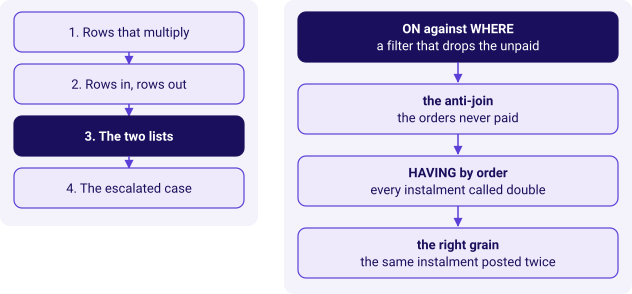

In [2]:
kit.side_by_side(
    kit.ladder(["Rows that multiply", "Rows in, rows out", "The two lists", "The escalated case"],
               lit=2, show=False),
    kit.vflow(["ON against WHERE\na filter that drops the unpaid",
               "the anti-join\nthe orders never paid",
               "HAVING by order\nevery instalment called double",
               "the right grain\nthe same instalment posted twice"], lit=0, show=False),
)

## 1. A condition on the right-hand table belongs in the ON clause

Anand wants what was collected in the quarter, so a hurried analyst keeps the LEFT JOIN from round
2 and adds the quarter's date range on `paid_date` in the WHERE clause.

**The plausible wrong answer** is the query below, on the invented tables, where T-4 was never paid.

**Predict before you run.** How many rows come back? a) 7, the same as the plain LEFT JOIN; b) 6,
and T-4 is gone; c) 5, one per order; d) 8.

In [3]:
where_rows = run("""
SELECT o.order_id, o.amount AS booked, p.payment_id, p.paid_date
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
WHERE p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
ORDER BY o.order_id, p.payment_id
""")
show(where_rows, "Invented: LEFT JOIN with the date filter in WHERE", money=["booked"])

order_id,booked,payment_id,paid_date
T-1,"Rs 1,000",P-1,2026-07-03
T-2,"Rs 2,000",P-2,2026-07-05
T-2,"Rs 2,000",P-3,2026-08-05
T-3,"Rs 1,500",P-4,2026-07-09
T-3,"Rs 1,500",P-5,2026-07-09
T-5,Rs 500,P-6,2026-07-12


**Why it is wrong.** The answer is b, six rows, the same six an INNER JOIN returns. WHERE runs after
the join has built its rows, and T-4's row carries NULL in `paid_date`; `NULL BETWEEN ...` is not
true, so the row is removed. The LEFT JOIN was written correctly and turned into an INNER one, and
an unpaid list built on it comes back empty, which tells Anand that every order was paid.

The check is the one from round 2, orders in against orders out. **The fix** moves the condition
into the ON clause, where it limits which payments match without removing any order.

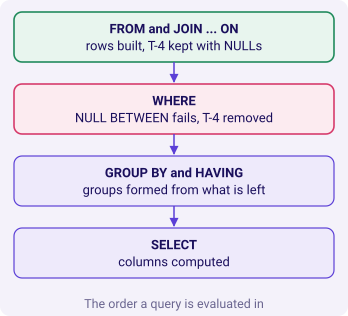

In [4]:
kit.vflow(["FROM and JOIN ... ON\nrows built, T-4 kept with NULLs",
           "WHERE\nNULL BETWEEN fails, T-4 removed",
           "GROUP BY and HAVING\ngroups formed from what is left",
           "SELECT\ncolumns computed"],
          kinds=["good", "bad", "plain", "plain"], title="The order a query is evaluated in")
orders_out = len({r["order_id"] for r in where_rows})
kit.check("the check catches it: the WHERE version returns fewer orders than the table holds",
          orders_out < 5, f"{orders_out} orders of 5")
kit.check("the WHERE version returns exactly the INNER JOIN's rows",
          len(where_rows) == run("SELECT count(*) AS n FROM tiny_orders o JOIN tiny_payments p ON p.order_id = o.order_id")[0]["n"],
          f"{len(where_rows)} rows")

order_id,booked,payment_id,paid_date
T-1,"Rs 1,000",P-1,2026-07-03
T-2,"Rs 2,000",P-2,2026-07-05
T-2,"Rs 2,000",P-3,2026-08-05
T-3,"Rs 1,500",P-4,2026-07-09
T-3,"Rs 1,500",P-5,2026-07-09
T-4,Rs 800,NULL,NULL
T-5,Rs 500,P-6,2026-07-12


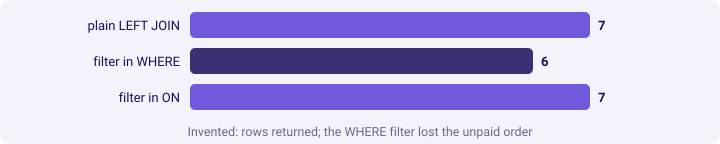

In [5]:
on_rows = run("""
SELECT o.order_id, o.amount AS booked, p.payment_id, p.paid_date
FROM tiny_orders o
LEFT JOIN tiny_payments p
       ON p.order_id = o.order_id
      AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
ORDER BY o.order_id, p.payment_id
""")
show(on_rows, "Invented: the same filter in the ON clause", money=["booked"])
plain = run("SELECT count(*) AS n FROM tiny_orders o LEFT JOIN tiny_payments p ON p.order_id = o.order_id")[0]["n"]
kit.bars([("plain LEFT JOIN", plain), ("filter in WHERE", len(where_rows)), ("filter in ON", len(on_rows))],
         lit=[1], title="Invented: rows returned; the WHERE filter lost the unpaid order")

In [6]:
kit.check("the ON version keeps all five orders", len({r["order_id"] for r in on_rows}) == 5, f"{len(on_rows)} rows")
kit.check("T-4 survives with NULLs on the payment side",
          any(r["order_id"] == "T-4" and r["payment_id"] is None for r in on_rows), "T-4, NULL")

**Your turn on Kalpa.** Count the rows both ways on Q2 and say in one sentence how many orders the
WHERE version lost and what the unpaid list would have said. Type these lines into the empty cell
below:

```python
for place, q in [("WHERE", "ON p.order_id = o.order_id WHERE o.quarter = 'Q2' AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'"),
                 ("ON", "ON p.order_id = o.order_id AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30' WHERE o.quarter = 'Q2'")]:
    r = run(f"SELECT count(*) AS rows_out, count(DISTINCT o.order_id) AS orders_out FROM orders o LEFT JOIN payments p {q}")[0]
    print(place, r)
```

In [7]:
_w = run("""SELECT count(DISTINCT o.order_id) AS n FROM orders o LEFT JOIN payments p ON p.order_id = o.order_id
            WHERE o.quarter = 'Q2' AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'""")[0]["n"]
_o = run("""SELECT count(DISTINCT o.order_id) AS n FROM orders o LEFT JOIN payments p ON p.order_id = o.order_id
            AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30' WHERE o.quarter = 'Q2'""")[0]["n"]
_i = run("""SELECT count(DISTINCT o.order_id) AS n FROM orders o JOIN payments p ON p.order_id = o.order_id
            WHERE o.quarter = 'Q2'""")[0]["n"]
kit.check("on Kalpa, the ON version keeps every Q2 order", _o == 462)
kit.check("on Kalpa, the WHERE version loses orders and matches the INNER join", _w < _o and _w == _i)

## 2. The anti-join lists the orders with no payment

The unpaid list is the one place where a WHERE on the right-hand table belongs: after a LEFT JOIN,
a NULL in the payment's key means no payment matched, so filtering for it keeps exactly the orders
with no partner. `NOT EXISTS` asks the same question in the words Anand used.

**Predict before you run.** Which condition, after `LEFT JOIN tiny_payments p`, keeps only the
unpaid orders? a) `WHERE p.amount = 0`; b) `WHERE p.payment_id IS NULL`; c) `WHERE o.status <>
'delivered'`; d) `WHERE p.paid_date > '2026-09-30'`.

order_id,channel,booked
T-4,app,Rs 800


payment_id,order_id,amount
P-7,T-9,Rs 600


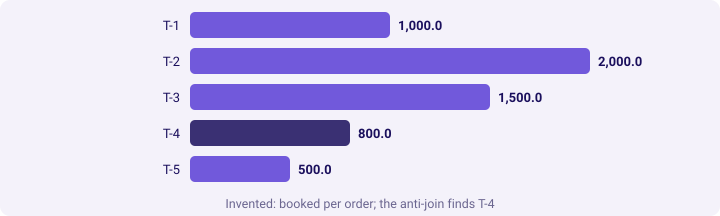

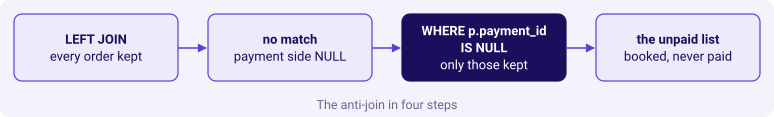

In [8]:
unpaid_tiny = run("""
SELECT o.order_id, o.channel, o.amount AS booked
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
WHERE p.payment_id IS NULL
""")
unpaid_tiny_ne = run("""
SELECT o.order_id, o.channel, o.amount AS booked
FROM tiny_orders o
WHERE NOT EXISTS (SELECT 1 FROM tiny_payments p WHERE p.order_id = o.order_id)
""")
orphans_tiny = run("""
SELECT p.payment_id, p.order_id, p.amount
FROM tiny_payments p
LEFT JOIN tiny_orders o ON o.order_id = p.order_id
WHERE o.order_id IS NULL
""")
show(unpaid_tiny, "Invented: the unpaid list, by anti-join", money=["booked"])
show(orphans_tiny, "Invented: the reverse anti-join, payments no order can claim", money=["amount"])
tiny_orders = run("SELECT order_id, amount FROM tiny_orders ORDER BY order_id")
kit.bars([(r["order_id"], float(r["amount"])) for r in tiny_orders], lit=[3],
         title="Invented: booked per order; the anti-join finds T-4")
kit.flow(["LEFT JOIN\nevery order kept", "no match\npayment side NULL", "WHERE p.payment_id IS NULL\nonly those kept",
          "the unpaid list\nbooked, never paid"], lit=2, title="The anti-join in four steps")

**What happened.** The answer is b. T-4 is the one order with no payment, and its 800 is exactly the
never-paid move of round 2's bridge, so the list and the bridge agree. Option a finds nothing,
because an unpaid order has no payment row with any amount; option c tests the order's status,
which says nothing about money; option d filters on a date that is NULL for the unpaid order. The
reverse anti-join finds P-7, the payment whose order is missing, which goes to the data platform
lead instead of Anand.

In [9]:
kit.check("the anti-join and NOT EXISTS return the same orders",
          [r["order_id"] for r in unpaid_tiny] == [r["order_id"] for r in unpaid_tiny_ne], "T-4")
kit.check("the unpaid list's booked equals the bridge's never-paid move", sum(r["booked"] for r in unpaid_tiny) == 800, "800")
kit.check("the reverse anti-join finds only the orphan payment", [r["payment_id"] for r in orphans_tiny] == ["P-7"], "P-7")

**Your turn on Kalpa.** Build Anand's first list. Type these lines into the empty cell below, read the
count first and the rows second, and write one sentence on which channel carries the most unpaid
value:

```python
unpaid = run("""
SELECT o.order_id, o.channel, o.status, o.amount AS booked
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2' AND p.payment_id IS NULL
ORDER BY o.amount DESC, o.order_id
""")
print(len(unpaid), "Q2 orders with no payment")
show(unpaid, "Your unpaid list for Q2", money=["booked"])
by_ch = {}
for r in unpaid:
    by_ch[r["channel"]] = by_ch.get(r["channel"], 0) + float(r["booked"])
kit.bars(sorted(by_ch.items()), title="Unpaid booked value by channel, Rs")
```

In [10]:
_anti = {r["order_id"] for r in run("""SELECT o.order_id FROM orders o LEFT JOIN payments p ON p.order_id = o.order_id
                                        WHERE o.quarter = 'Q2' AND p.payment_id IS NULL""")}
_ne = {r["order_id"] for r in run("""SELECT o.order_id FROM orders o WHERE o.quarter = 'Q2'
                                      AND NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id = o.order_id)""")}
_b = run(BRIDGE_SQL)[0]
_unpaid_booked = run("SELECT coalesce(sum(amount), 0) AS s FROM orders WHERE order_id = ANY(%s)", (list(_anti),))[0]["s"]
kit.check("on Kalpa, the anti-join and NOT EXISTS return the same Q2 orders", _anti == _ne and len(_anti) > 0)
kit.check("on Kalpa, the unpaid list's booked equals booked minus collected from the bridge",
          _unpaid_booked == _b["booked"] - _b["collected"])

## 3. HAVING COUNT(*) > 1 by order calls every instalment a double payment

**The plausible wrong answer.** The data platform lead said the gateway sometimes double-posts, so a
hurried analyst lists every order with more than one payment row and calls it the double-paid list.

**Predict before you run.** On the invented tables, which orders does it list? a) T-3 only; b) T-2
and T-3; c) T-2 only; d) none.

In [11]:
naive_tiny = run("""
SELECT order_id, count(*) AS payment_rows, sum(amount) AS posted,
       string_agg(instalment_no::text, ' and ' ORDER BY instalment_no) AS instalments
FROM tiny_payments
GROUP BY order_id
HAVING count(*) > 1
ORDER BY order_id
""")
show(naive_tiny, "Invented: every order with more than one payment row", money=["posted"])

order_id,payment_rows,posted,instalments
T-2,2,"Rs 2,000",1 and 2
T-3,2,"Rs 3,000",1 and 1


**What happened.** The answer is b. T-3 is a retry: instalment 1, posted twice, same amount, same
day. T-2 is a customer paying as agreed: instalments 1 and 2. The list cannot tell them apart,
because it groups at the order, and at the order both look like "two rows". On Kalpa the same query
runs over every Q2 order, and the large invoices are the ones settled in two instalments.

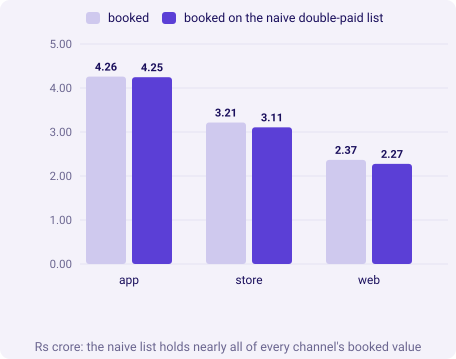

In [12]:
naive = run("""
SELECT o.channel, count(*) AS orders_listed, sum(o.amount) AS booked_on_list
FROM orders o
WHERE o.quarter = 'Q2'
  AND o.order_id IN (SELECT order_id FROM payments GROUP BY order_id HAVING count(*) > 1)
GROUP BY o.channel
ORDER BY o.channel
""")
listed = sum(r["orders_listed"] for r in naive)
listed_value = sum(r["booked_on_list"] for r in naive)
booked_q2 = run("SELECT sum(amount) AS s FROM orders WHERE quarter = 'Q2'")[0]["s"]
kit.stats([(f"{listed}", "orders on the list", "Q2 orders with more than one payment row"),
           (kit.rupees(listed_value), "booked on the list", "the value a refund desk would chase"),
           (f"{100 * listed_value / booked_q2:.1f}%", "of Q2 booked", "on a list meant to hold exceptions")])
by_ch_booked = {r["channel"]: r["booked"] for r in run(
    "SELECT channel, sum(amount) AS booked FROM orders WHERE quarter = 'Q2' GROUP BY channel ORDER BY channel")}
kit.columns([r["channel"] for r in naive],
            [("booked", [float(by_ch_booked[r["channel"]]) for r in naive]),
             ("booked on the naive double-paid list", [float(r["booked_on_list"]) for r in naive])],
            fmt=crore, title="Rs crore: the naive list holds nearly all of every channel's booked value")

**Why it is wrong.** The list holds 216 Q2 orders worth Rs 9,62,59,340 booked, 97.8 percent of the
quarter. Sent to the refund desk, it starts a chase of about Rs 9.6 crore of "double payments" that
are legitimate second instalments, and it calls customers who paid exactly as invoiced. An
exception list that holds nearly everything is the signal that the grain is wrong. The check is the
instalment numbers inside each group: two different instalments cannot be a retry.

In [13]:
_mixed = run("""
SELECT count(*) AS n FROM (
    SELECT p.order_id FROM payments p JOIN orders o ON o.order_id = p.order_id
    WHERE o.quarter = 'Q2' GROUP BY p.order_id
    HAVING count(*) > 1 AND count(DISTINCT p.instalment_no) > 1) x""")[0]["n"]
kit.check("the check catches it: T-2 on the invented list carries two different instalments",
          [r["instalments"] for r in naive_tiny if r["order_id"] == "T-2"] == ["1 and 2"], "T-2: 1 and 2")
kit.check("on Kalpa, most orders on the naive list carry two different instalments, which no retry can",
          _mixed > listed / 2)
kit.check("the naive list holds more than nine tenths of Q2 booked, far too much for an exception list",
          listed_value / booked_q2 > 0.9, f"{listed_value / booked_q2:.1%}")

## 4. A retry is the same instalment posted twice

The fix changes the grain of the GROUP BY. A retry repeats one instalment of one order, so the
group is the order and the instalment, and a group with more than one row is a payment the gateway
posted again. The surplus is the amount times the extra postings.

**Predict before you run.** Which grain lists only the retry on the invented tables? a) `GROUP BY
order_id`; b) `GROUP BY order_id, paid_date`; c) `GROUP BY order_id, instalment_no`; d) `GROUP BY
payment_id`.

order_id,instalment_no,times_posted,amount,posted_twice
T-3,1,2,"Rs 1,500","Rs 1,500"


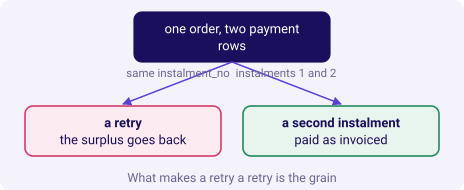

In [14]:
fixed_tiny = run("""
SELECT order_id, instalment_no, count(*) AS times_posted, max(amount) AS amount,
       max(amount) * (count(*) - 1) AS posted_twice
FROM tiny_payments
GROUP BY order_id, instalment_no
HAVING count(*) > 1
""")
show(fixed_tiny, "Invented: the same instalment posted more than once", money=["amount", "posted_twice"])
kit.tree({"label": "one order, two payment rows", "kind": "lit", "branches": [
    ("same instalment_no", {"label": "a retry\nthe surplus goes back", "kind": "bad"}),
    ("instalments 1 and 2", {"label": "a second instalment\npaid as invoiced", "kind": "good"})]},
    taken=["same instalment_no"], title="What makes a retry a retry is the grain")

**What happened.** The answer is c: only T-3 is listed, with 1,500 posted twice, which is the bridge's
posted-twice move exactly. Option a is the naive list; option b would also catch T-3 here, and
would miss a retry the gateway posts the next day; option d groups each row with itself and finds
nothing.

**Your turn on Kalpa.** Build Anand's second list. Type these lines into the empty cell below, read
the count and the channels, and write one sentence on what the retries have in common:

```python
retries = run("""
SELECT p.order_id, o.channel, p.instalment_no, p.method, count(*) AS times_posted,
       max(p.amount) AS amount, max(p.amount) * (count(*) - 1) AS posted_twice
FROM payments p
JOIN orders o ON o.order_id = p.order_id
WHERE o.quarter = 'Q2'
GROUP BY p.order_id, o.channel, p.instalment_no, p.method
HAVING count(*) > 1
ORDER BY o.channel, p.order_id
""")
print(len(retries), "Q2 instalments posted more than once")
show(retries, "Your double-paid list for Q2", money=["amount", "posted_twice"])
```

In [15]:
_fixed = run("""
SELECT p.order_id, max(p.amount) * (count(*) - 1) AS surplus
FROM payments p JOIN orders o ON o.order_id = p.order_id
WHERE o.quarter = 'Q2'
GROUP BY p.order_id, p.instalment_no
HAVING count(*) > 1""")
_naive_ids = {r["order_id"] for r in run("""SELECT p.order_id FROM payments p JOIN orders o ON o.order_id = p.order_id
                                             WHERE o.quarter = 'Q2' GROUP BY p.order_id HAVING count(*) > 1""")}
kit.check("on Kalpa, every order on the fixed list is also on the naive list",
          {r["order_id"] for r in _fixed} <= _naive_ids)
kit.check("on Kalpa, the fixed list is far shorter than the naive list", 0 < len(_fixed) < len(_naive_ids) / 4)
kit.check("on Kalpa, the fixed list's surplus equals the bridge's posted-twice move",
          sum(r["surplus"] for r in _fixed) == _b["plus_posted_twice"])

> **Kavya's review.** "Two payment rows are not a double payment. Show me what makes a retry a retry
> before you call anyone about a refund."

Both lists now tie to the bridge. The unpaid list's booked value is booked minus collected, and the
double-paid list's surplus is posted minus collected, so the two lists together account for every
rupee between what Kalpa booked and what the feed shows. The escalated case puts them into one
report by channel that Anand can sign.

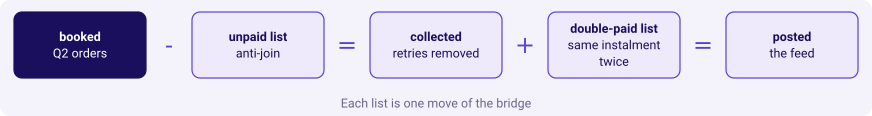

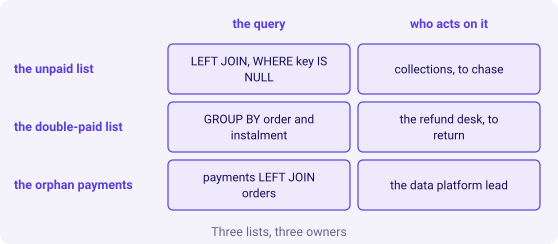

What you can now say,The evidence
A filter on the payments side goes in ON,invented: WHERE returned 6 rows and lost T-4; ON kept 7
The anti-join lists the unpaid orders,"invented: T-4, 800, the bridge's first move"
HAVING by order lists instalments as doubles,"Q2: 216 orders, Rs 9,62,59,340, 97.8 percent of booked"
Grouping by order and instalment finds the retries,"invented: T-3, 1,500, the bridge's second move"


In [16]:
kit.equation(["booked\nQ2 orders", "-", "unpaid list\nanti-join", "=", "collected\nretries removed",
              "+", "double-paid list\nsame instalment twice", "=", "posted\nthe feed"],
             title="Each list is one move of the bridge")
kit.matrix(["the unpaid list", "the double-paid list", "the orphan payments"],
           ["the query", "who acts on it"],
           [["LEFT JOIN, WHERE key IS NULL", "collections, to chase"],
            ["GROUP BY order and instalment", "the refund desk, to return"],
            ["payments LEFT JOIN orders", "the data platform lead"]],
           title="Three lists, three owners")
kit.table(["What you can now say", "The evidence"],
          [["A filter on the payments side goes in ON", "invented: WHERE returned 6 rows and lost T-4; ON kept 7"],
           ["The anti-join lists the unpaid orders", "invented: T-4, 800, the bridge's first move"],
           ["HAVING by order lists instalments as doubles", "Q2: 216 orders, Rs 9,62,59,340, 97.8 percent of booked"],
           ["Grouping by order and instalment finds the retries", "invented: T-3, 1,500, the bridge's second move"]],
          caption="What round 3 established")

### In the interview

**[F] How do you find orders with no payment?** "An anti-join. Either `LEFT JOIN payments p ON
p.order_id = o.order_id WHERE p.payment_id IS NULL`, testing a column that cannot be NULL on a real
payment, usually its key, or `WHERE NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id =
o.order_id)`, which reads as the question. I avoid `NOT IN (SELECT order_id FROM payments)`,
because a single NULL in the subquery makes it return nothing. Then I reconcile the list: its
booked total must equal booked minus collected, or the list is incomplete."

**[F] A filter on the right-hand table of a LEFT JOIN: WHERE or ON, and what changes?** "In ON, it
decides which right-hand rows match, and every left row survives, with NULLs where nothing matched.
In WHERE, it runs after the join, and the NULL rows fail it, so the LEFT JOIN behaves as an INNER
one and the unmatched rows disappear. The rule: a condition on the right-hand table goes in ON, and
the one WHERE that belongs on it is `IS NULL` on its key, for an anti-join."

**[F] HAVING COUNT(*) > 1 on payments by order: what does it find, and what does it wrongly
include?** "It finds every order with more than one payment row, which includes every order paid
in instalments as well as every retry. On Kalpa's Q2 that was 216 orders and nearly all of booked.
A retry is the same instalment posted twice, so the grain has to be order and instalment, and the
check is that the fixed list's surplus equals posted minus collected."

### Depth: NOT IN, semi-joins and what else a retry looks like

`NOT IN` compares with every value in the subquery, and a comparison with NULL is unknown, so one
NULL `order_id` in payments makes `o.order_id NOT IN (...)` unknown for every order and the list
comes back empty. `payments` here has no foreign key and no NOT NULL guarantee a report should rely
on, which is reason enough to use `NOT EXISTS`. Its mirror, `EXISTS`, is a semi-join: it keeps an
order once if any payment matches, and never multiplies it, so it is the safe way to ask "has at
least one payment" without a fan-out.

A retry in a real feed is not always a clean copy. A gateway can post the second copy a day later,
or with a new payment id and the same gateway reference. Grouping by order and instalment catches
both, because it ignores the date and the id. A feed without an instalment number needs another
key that identifies one intended payment, such as the gateway reference, and the analyst should ask
the platform lead which column that is before writing the query.

Practice tonight: SQLBolt lesson 7, outer joins,
https://sqlbolt.com/lesson/select_queries_with_outer_joins (verified 29 Sep 2026), and lesson 8, NULLs,
https://sqlbolt.com/lesson/select_queries_with_nulls (verified 29 Sep 2026). Stretch: PostgreSQL
Exercises, joins, https://pgexercises.com/questions/joins/ (verified 29 Sep 2026).

In [17]:
kit.check_summary()
print("Next: the escalated case, the report by channel Anand signs, with both lists and every payment row accounted for.")

Next: the escalated case, the report by channel Anand signs, with both lists and every payment row accounted for.
